# Reaction-time exploration

Exploratory notebook for channel-wise sliding-window RT prediction
(Pearson \(r\) from high-gamma → RT).

**Data:** `../results/{Task}(bipolar)(hammers)/RT/*_highgamma.h5`  
**Coords:** hammers HGA `*_coord.csv` (template `x,y,z` — **no** fsaverage→cvs translation).

### Roadmap
1. **Replicate** existing panels from `viz/fig5.ipynb` / `vizpub/fig3*.ipynb`
2. **Explore** onset latency, cross-task overlays, anatomy correlations, subject stability

Use conda env `ieeg`. Brain maps need offscreen / notebook 3D backend (compute node preferred).


In [1]:
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mne
import numpy as np
import pandas as pd
import pyvista as pv
import seaborn as sns
import xarray as xr
from IPython.display import display
from matplotlib.lines import Line2D
from mne.viz import Brain
from mne_bids import BIDSPath
from scipy.spatial import cKDTree
from tqdm.auto import tqdm

cm = 1 / 2.54
plt.rcParams['svg.fonttype'] = 'none'
fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
stg_color = '#20B2AA'
smc_color = '#6A5ACD'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)

mne.viz.set_3d_backend('notebook')


Using notebook 3d backend.


## Config


In [2]:
rt_ref = 'bipolar'
rt_atlas = 'hammers'
rt_tasks = ['LexicalDelay', 'PhonemeSequence', 'PictureNaming']
rt_description = 'Repeat'

RT_SIG_WINDOWS = {
    'Delay': (0.0, 0.8),
    'Go': (-0.5, 1.0),
    'Response': (-0.5, 1.0),
}

rt_hue_order = ['AIC', 'PIC', 'SMC']
rt_phases = ['Stimulus', 'Delay', 'Go', 'Response']
brain_roi_list = ['AIC', 'SMC', 'PIC', 'SFG', 'MFG', 'IFG', 'IFGs', 'SFGs', 'MFGs']

recon_dir = '/cwork/ns458/ECoG_Recon/'
FS_SUBJECT = 'cvs_avg35_inMNI152'
results_root = Path('..') / 'results'
export_dir = Path('../img/misc')  # exploration dumps; keep savefig commented

ROI_COLOR_MAP = {
    'AIC': red,
    'PIC': blue,
    'STG': stg_color,
    'SMC': 'black',
}

RT_EXCLUDE_ROIS = {
    'mOccG', 'OPC', 'Hipp', 'Central', 'Put', 'PhG', 'GRect', 'LinGs', 'CollatAnt',
    'LinG', 'Amyg', 'LatV', 'InfLatV', 'PCun', 'CC_Central(unknown)', 'Cun', 'VDC',
    'BrainStem(unknown)', 'Intersection', 'OFCs', 'iOccGs', 'Calcarine', 'Thal',
    'OccS', 'FuGs', 'Paracentral', 'PCuns', 'SFGs', 'MFGs', 'IFGs', 'CGs',
    'Unknown', 'BrainStem', 'CC', 'Caud', 'GSubcallosal', 'BrainStem–Thal',
}


def rt_results_root(task: str) -> Path:
    return results_root / f'{task}({rt_ref})({rt_atlas})'


def roi_colors_for(rois):
    return [ROI_COLOR_MAP.get(r, 'gray') for r in rois]


## Load electrode coordinates

Hammers packaged template coords (same as `vizpub/fig1.ipynb`). Do **not** apply the
legacy fsaverage→cvs mean translation from `fig3_rt_legacy`.


In [3]:
coord_paths = []
for task in rt_tasks:
    coord_paths.extend(
        BIDSPath(
            root=str(rt_results_root(task)),
            datatype='HGA',
            suffix='coord',
            check=False,
        ).match()
    )

if not coord_paths:
    raise FileNotFoundError(
        f'No HGA coord CSVs under results/{{task}}({rt_ref})({rt_atlas})/'
    )

coords = pd.concat(
    [pd.read_csv(p) for p in tqdm(coord_paths, desc='load HGA coord')],
    ignore_index=True,
)
coords = coords.dropna(subset=['x', 'y', 'z']).copy()

coords.loc[coords['roi'] == 'PrG', 'roi'] = 'SMC'
coords.loc[coords['roi'] == 'PoG', 'roi'] = 'SMC'
coords.loc[coords['roi'] == 'Subcentral', 'roi'] = 'SMC'
coords.loc[coords['roi'] == 'STGp', 'roi'] = 'STG'
coords.loc[coords['roi'] == 'STGa', 'roi'] = 'STG'
coords.loc[coords['roi'] == 'HG', 'roi'] = 'STG'

elec_coords = (
    coords[['channel', 'roi', 'label', 'hemi', 'x', 'y', 'z']]
    .drop_duplicates(subset=['channel'])
    .reset_index(drop=True)
)

print(
    f'Unique electrodes: {len(elec_coords)} | '
    f'top ROIs: {elec_coords["roi"].value_counts().head(8).to_dict()}'
)
elec_coords.head()


load HGA coord:   0%|          | 0/1071 [00:00<?, ?it/s]

Unique electrodes: 13672 | top ROIs: {'Unknown': 5119, 'pTL': 923, 'MTG': 762, 'MFG': 731, 'STG': 664, 'SMC': 631, 'OFC': 431, 'SFG': 413}


,channel,roi,label,hemi,x,y,z
0,D0023_R1MF1-2,Unknown,0,R,10.17779,26.21872,19.1570
1,D0023_R1MF2-3,CG,CG anterior cingulate gyrus R,R,13.23130,25.98320,18.8735
2,D0023_R1MF9-10,Unknown,0,R,38.74180,20.16062,18.0023
3,D0023_R1MF10-11,Unknown,0,R,42.43860,20.31028,18.2268
4,D0023_R1MF11-12,MFG,FL middle frontal gyrus R,R,45.58940,20.66959,18.5661


## Load RT H5 results

Long table: `r2` = Pearson \(r\) (legacy column name), plus `mask` / p-values.


In [4]:
RT_COLUMNS = [
    'channel', 'time', 'r2', 'perm_r2_mean', 'pval', 'cluster_pval', 'mask',
    'subject', 'phase', 'description', 'band', 'task',
]


def _empty_rt() -> pd.DataFrame:
    return pd.DataFrame(columns=RT_COLUMNS)


def _rt_h5_to_long_df(path, task: str) -> pd.DataFrame:
    with h5py.File(path, 'r') as mat:
        score = mat['score'][()]
        time = mat['time'][()]
        channels = [
            ch.decode('utf-8') if isinstance(ch, (bytes, np.bytes_)) else str(ch)
            for ch in mat['channels'][:]
        ]
        pval = mat['pval'][()]
        cluster_pval = mat['cluster_pval'][()]
        mask = mat['mask'][()]
        if 'perm_r2' in mat:
            perm = mat['perm_r2'][()]
        elif 'perm_score' in mat:
            perm = mat['perm_score'][()]
        else:
            perm = None

    perm_mean = perm.mean(axis=-1) if perm is not None else np.full_like(score, np.nan)

    def _wide_to_long(values, name):
        df = pd.DataFrame(values, index=channels, columns=time).reset_index()
        df = df.rename(columns={'index': 'channel'})
        return df.melt(id_vars='channel', var_name='time', value_name=name)

    df = _wide_to_long(score, 'r2')
    df = df.merge(_wide_to_long(perm_mean, 'perm_r2_mean'), on=['channel', 'time'], how='left')
    df = df.merge(_wide_to_long(pval, 'pval'), on=['channel', 'time'], how='left')
    df = df.merge(_wide_to_long(cluster_pval, 'cluster_pval'), on=['channel', 'time'], how='left')
    df = df.merge(_wide_to_long(mask, 'mask'), on=['channel', 'time'], how='left')
    df['mask'] = df['mask'].astype(bool)
    df['subject'] = path.subject
    df['phase'] = path.processing
    df['description'] = path.description
    df['band'] = path.suffix
    df['task'] = task
    return df


def load_reaction_time(
    tasks,
    *,
    ref='bipolar',
    atlas='hammers',
    description='Repeat',
    results_root=Path('..') / 'results',
) -> pd.DataFrame:
    frames = []
    results_root = Path(results_root)
    for task in tasks:
        root = results_root / f'{task}({ref})({atlas})'
        if not root.exists():
            warnings.warn(f'Missing RT results directory: {root}')
            continue
        paths = BIDSPath(
            datatype='RT', root=str(root), suffix='highgamma', check=False,
        ).match()
        if not paths:
            warnings.warn(f'No RT H5 for task={task}')
            continue
        for path in tqdm(paths, desc=f'RT {task}'):
            try:
                frames.append(_rt_h5_to_long_df(path, task))
            except OSError as exc:
                warnings.warn(f'Skip {path}: {exc}')
    if not frames:
        return _empty_rt()
    rt = pd.concat(frames, ignore_index=True)
    if description is not None:
        rt = rt[rt['description'] == description]
    rt['time'] = pd.to_numeric(rt['time'], errors='coerce')
    return rt.reset_index(drop=True)


rt = load_reaction_time(
    rt_tasks, ref=rt_ref, atlas=rt_atlas,
    description=rt_description, results_root=results_root,
)
print(f'RT rows: {len(rt):,}')
if not rt.empty:
    print(rt.groupby('task')['subject'].nunique().rename('n_subjects'))
    print('phases:', sorted(rt['phase'].unique()))
rt.head()


RT LexicalDelay:   0%|          | 0/384 [00:00<?, ?it/s]

RT PhonemeSequence:   0%|          | 0/184 [00:00<?, ?it/s]

RT PictureNaming:   0%|          | 0/128 [00:00<?, ?it/s]

RT rows: 4,307,776
task
LexicalDelay       48
PhonemeSequence    46
PictureNaming      32
Name: n_subjects, dtype: int64
phases: ['Delay', 'Go', 'Response', 'Stimulus']


,channel,time,r2,perm_r2_mean,pval,cluster_pval,mask,subject,phase,description,band,task
0,D0023_R1MF11-12,-0.8,0.062158,-0.000343,0.195609,0.195609,False,D0023,Delay,Repeat,highgamma,LexicalDelay
1,D0023_R1MF12-13,-0.8,-0.017465,-0.005325,0.568862,0.568862,False,D0023,Delay,Repeat,highgamma,LexicalDelay
2,D0023_R1MF13-14,-0.8,-0.138072,-0.000127,0.944112,0.944112,False,D0023,Delay,Repeat,highgamma,LexicalDelay
3,D0023_R1MF14-15,-0.8,0.148936,-0.003730,0.031936,0.031936,False,D0023,Delay,Repeat,highgamma,LexicalDelay
4,D0023_R1MF15-16,-0.8,0.014417,0.007984,0.483034,0.483034,False,D0023,Delay,Repeat,highgamma,LexicalDelay


## Significant channel subset

Merge coords, drop excluded ROIs, keep channels with cluster-significant `mask` in
Delay / Go / Response windows (legacy rule).


In [5]:
if rt.empty:
    rt_subset = _empty_rt()
    print('No RT data loaded.')
else:
    rt_ = rt[rt['channel'].isin(elec_coords['channel'])].merge(
        elec_coords, on='channel', how='left',
    )
    rt_ = rt_[~rt_['roi'].isin(RT_EXCLUDE_ROIS)].copy()

    sig_sets = []
    for phase, (t0, t1) in RT_SIG_WINDOWS.items():
        phase_mask = (
            (rt_['phase'] == phase)
            & (rt_['time'] >= t0)
            & (rt_['time'] <= t1)
            & (rt_['mask'])
        )
        sig_sets.append(set(rt_.loc[phase_mask, 'channel'].unique()))

    sig_channels = set().union(*sig_sets)
    rt_subset = rt_[rt_['channel'].isin(sig_channels)].copy()
    print(
        f'after coord merge: {rt_["channel"].nunique()} ch | '
        f'significant: {len(sig_channels)} | rows={len(rt_subset):,}'
    )
    print(rt_subset.groupby('task')['channel'].nunique().rename('n_sig_ch'))

rt_subset.head()


after coord merge: 5840 ch | significant: 3987 | rows=2,807,664
task
LexicalDelay       2269
PhonemeSequence    1587
PictureNaming      2195
Name: n_sig_ch, dtype: int64


,channel,time,r2,perm_r2_mean,pval,cluster_pval,mask,subject,phase,description,band,task,roi,label,hemi,x,y,z
0,D0023_R1MF11-12,-0.8,0.062158,-0.000343,0.195609,0.195609,False,D0023,Delay,Repeat,highgamma,LexicalDelay,MFG,FL middle frontal gyrus R,R,45.5894,20.66959,18.5661
1,D0023_R1MF12-13,-0.8,-0.017465,-0.005325,0.568862,0.568862,False,D0023,Delay,Repeat,highgamma,LexicalDelay,MFG–PrG,0,R,49.5555,20.88449,18.2081
2,D0023_R1MF13-14,-0.8,-0.138072,-0.000127,0.944112,0.944112,False,D0023,Delay,Repeat,highgamma,LexicalDelay,SMC,FL precentral gyrus R,R,54.5756,20.56080,18.0645
3,D0023_R1MF14-15,-0.8,0.148936,-0.003730,0.031936,0.031936,False,D0023,Delay,Repeat,highgamma,LexicalDelay,SMC,0,R,59.0700,20.16265,18.1869
4,D0023_R1MF15-16,-0.8,0.014417,0.007984,0.483034,0.483034,False,D0023,Delay,Repeat,highgamma,LexicalDelay,SMC,0,R,62.3834,20.18222,18.1781


---
# Part 1 — Replicate existing panels


## 1. Delay ROI electrode counts (+ rose)

Replicates `viz/fig5` / `vizpub/fig3` Delay spatial summaries.


Delay significant channels (filtered): 1913


,roi,n_electrodes
70,STG,236
76,pTL,233
60,SMC,224
37,MFG,205
41,MTG,159
29,IFG,114
58,SFG,90
1,AIC,79
43,OFC,79
12,CG,68


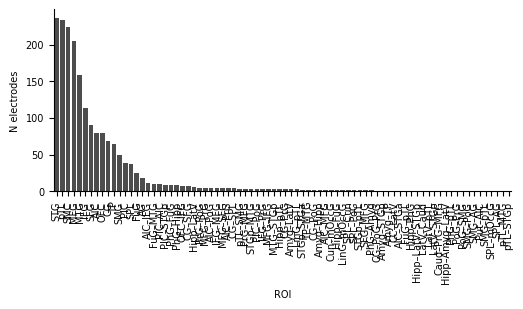

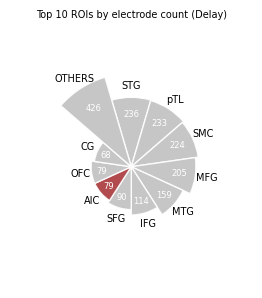

In [6]:
def rt_delay_channel_table(rt_subset: pd.DataFrame) -> pd.DataFrame:
    rt_phase = rt_subset[rt_subset['phase'] == 'Delay']
    sig_ch = rt_phase.loc[rt_phase['mask'], 'channel'].unique()
    subset = rt_phase[rt_phase['channel'].isin(sig_ch)].copy()
    if subset.empty:
        return subset
    g = subset.groupby('channel')['r2']
    picks = g.min().ge(-1) & g.max().le(1) & g.max().gt(0)
    picks = picks[picks].index
    subset = subset[subset['channel'].isin(picks)]
    return (
        subset.groupby('channel')
        .agg(
            r2=('r2', 'mean'),
            x=('x', 'first'), y=('y', 'first'), z=('z', 'first'),
            roi=('roi', 'first'), label=('label', 'first'),
            phase=('phase', 'first'), hemi=('hemi', 'first'),
            subject=('subject', 'first'), task=('task', 'first'),
        )
        .reset_index()
    )


rt_delay_coords = rt_delay_channel_table(rt_subset)
print(f'Delay significant channels (filtered): {len(rt_delay_coords)}')

if rt_delay_coords.empty:
    print('Skipping ROI count plots.')
else:
    roi_counts = (
        rt_delay_coords[['roi', 'channel']]
        .dropna().drop_duplicates()
        .groupby('roi', as_index=False)
        .agg(n_electrodes=('channel', 'nunique'))
        .sort_values('n_electrodes', ascending=False)
    )
    display(roi_counts.head(10))

    fig, ax = plt.subplots(figsize=(15 * cm, 6 * cm))
    sns.barplot(
        data=roi_counts, x='roi', y='n_electrodes',
        order=roi_counts['roi'], color='0.3', ax=ax,
    )
    ax.set_xlabel('ROI', fontdict=fontdict)
    ax.set_ylabel('N electrodes', fontdict=fontdict)
    ax.tick_params(axis='x', rotation=90, labelsize=fontsize)
    ax.tick_params(axis='y', labelsize=fontsize)
    sns.despine(ax=ax)
    # fig.savefig(export_dir / 'rt_explore_roi_counts_delay.svg', dpi=300, bbox_inches='tight')
    plt.show()

    top_n = 10
    sorted_ = roi_counts.sort_values('n_electrodes', ascending=False)
    plot_df = pd.concat(
        [
            sorted_.iloc[:top_n].copy(),
            pd.DataFrame({
                'roi': ['OTHERS'],
                'n_electrodes': [sorted_.iloc[top_n:]['n_electrodes'].sum()],
            }),
        ],
        ignore_index=True,
    )
    values = plot_df['n_electrodes'].to_numpy()
    labels = plot_df['roi'].to_numpy()
    radii = np.sqrt(values)
    n = len(values)
    theta = np.linspace(0.0, 2 * np.pi, n, endpoint=False)
    width = 2 * np.pi / n if n else 2 * np.pi
    rose_colors = [
        red if lab == 'AIC' else blue if lab == 'PIC' else '#C0C0C0' for lab in labels
    ]
    fig, ax = plt.subplots(figsize=(8 * cm, 8 * cm), subplot_kw={'projection': 'polar'})
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.bar(theta, radii, width=width, bottom=0.0,
           color=rose_colors, edgecolor='white', linewidth=1, alpha=0.9)
    max_r = float(radii.max()) if len(radii) else 1.0
    ax.set_ylim(0, max_r * 1.3)
    ax.grid(False)
    ax.spines['polar'].set_visible(False)
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    for t, r, v, lab in zip(theta, radii, values, labels):
        ax.text(t, r + max_r * 0.12, f'{lab}', ha='center', va='center', fontsize=fontsize)
        if r > 0.45:
            ax.text(t, r * 0.75, f'{int(v)}', ha='center', va='center',
                    fontsize=fontsize - 1, color='white')
    ax.set_title(f'Top {top_n} ROIs by electrode count (Delay)', fontsize=fontsize, pad=20)
    # fig.savefig(export_dir / 'rt_explore_roi_rose_delay.svg', dpi=300, bbox_inches='tight')
    plt.show()


## 2. Delay brain map

Legacy `fig3_rt_legacy` method: project template xyz → nearest cvs pial vertex,
`plotter.add_mesh` spheres colored/sized by mean \(r\).


Electrode→pial mm: mean=1.98, median=1.62, p95=4.59


2026-07-18 13:59:43.274 ( 243.479s) [    7FA3377A7740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-18 13:59:43.325 ( 243.530s) [    7FA3377A7740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x2784f9f0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl

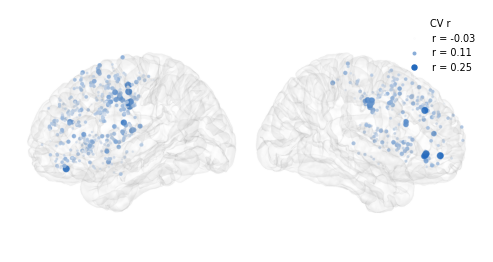

In [7]:
import os
os.environ.setdefault('PYVISTA_OFF_SCREEN', 'true')
pv.OFF_SCREEN = True
mne.viz.set_3d_backend('notebook')

if rt_delay_coords.empty:
    print('Skipping brain map.')
else:
    brain_df = (
        rt_delay_coords[rt_delay_coords['roi'].isin(brain_roi_list)]
        .dropna(subset=['x', 'y', 'z'])
        .copy()
    )
    if brain_df.empty:
        print('No channels in brain_roi_list.')
    else:
        coords_xyz = brain_df[['x', 'y', 'z']].to_numpy(dtype=float)
        vals = brain_df['r2'].to_numpy(dtype=float)

        vmin = float(np.nanpercentile(vals, 2))
        vmax = float(np.nanpercentile(vals, 99))
        if not np.isfinite(vmin):
            vmin = float(np.nanmin(vals))
        if not np.isfinite(vmax):
            vmax = float(np.nanmax(vals))
        if vmin == vmax:
            vmax = vmin + 1e-6
        cmap = blues
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        sizes = 10 + 30 * np.clip((vals - vmin) / (vmax - vmin), 0, 1)

        lh_coords, _ = mne.read_surface(f'{recon_dir}/{FS_SUBJECT}/surf/lh.pial')
        rh_coords, _ = mne.read_surface(f'{recon_dir}/{FS_SUBJECT}/surf/rh.pial')
        d_all, _ = cKDTree(np.vstack([lh_coords, rh_coords])).query(coords_xyz)
        print(
            f'Electrode→pial mm: mean={d_all.mean():.2f}, '
            f'median={np.median(d_all):.2f}, p95={np.percentile(d_all, 95):.2f}'
        )
        if d_all.mean() > 15:
            raise RuntimeError(
                'Coords far from cvs pial — check for leftover fsaverage translation.'
            )

        lh_tree, rh_tree = cKDTree(lh_coords), cKDTree(rh_coords)
        lh = Brain(
            FS_SUBJECT, subjects_dir=recon_dir, hemi='lh', surf='pial',
            background='white', show=False, cortex=(0.9, 0.9, 0.9), alpha=0.1,
            size=(600 * cm, 600 * cm),
        )
        rh = Brain(
            FS_SUBJECT, subjects_dir=recon_dir, hemi='rh', surf='pial',
            background='white', show=False, cortex=(0.9, 0.9, 0.9), alpha=0.1,
            size=(600 * cm, 600 * cm),
        )

        mask_lh = coords_xyz[:, 0] < 0
        mask_rh = coords_xyz[:, 0] > 0
        if mask_lh.any():
            _, idx = lh_tree.query(coords_xyz[mask_lh])
            for pt, v, s in zip(lh_coords[idx], vals[mask_lh], sizes[mask_lh]):
                lh._renderer.plotter.add_mesh(
                    pv.PolyData(pt.reshape(1, 3)),
                    render_points_as_spheres=True, point_size=float(s),
                    color=cmap(norm(v))[:3], lighting=False, opacity=0.95,
                )
        if mask_rh.any():
            _, idx = rh_tree.query(coords_xyz[mask_rh])
            for pt, v, s in zip(rh_coords[idx], vals[mask_rh], sizes[mask_rh]):
                rh._renderer.plotter.add_mesh(
                    pv.PolyData(pt.reshape(1, 3)),
                    render_points_as_spheres=True, point_size=float(s),
                    color=cmap(norm(v))[:3], lighting=False, opacity=0.95,
                )

        for b in (lh, rh):
            b.show_view(view='lateral', distance=400)
            b._renderer.plotter.window_size = [1400, 1400]

        fig, (ax1, ax2) = plt.subplots(
            1, 2, figsize=(16 * cm, 8 * cm), gridspec_kw={'width_ratios': [1, 1]},
        )
        plt.subplots_adjust(wspace=-0.1)
        ax1.imshow(lh.screenshot(mode='rgb')); ax1.axis('off')
        ax2.imshow(rh.screenshot(mode='rgb')); ax2.axis('off')
        example_r2 = [vmin, (vmin + vmax) / 2, vmax]
        example_sizes = 1 + 35 * np.clip(
            (np.array(example_r2) - vmin) / (vmax - vmin), 0, 1,
        )
        handles = [
            Line2D(
                [0], [0], marker='o', linestyle='None',
                markerfacecolor=cmap(norm(r2_val)),
                markeredgecolor=cmap(norm(r2_val)),
                markersize=size * 0.1,
                label=f'r = {r2_val:.2f}',
            )
            for r2_val, size in zip(example_r2, example_sizes)
        ]
        ax2.legend(
            handles=handles, title='CV r', loc='upper right', frameon=False,
            fontsize=7, title_fontsize=7,
        )
        lh.close(); rh.close()
        # fig.savefig(export_dir / 'rt_explore_spatial_delay.svg', dpi=300, bbox_inches='tight')
        plt.show()


## 3. Temporal \(r(t)\) curves by ROI

Mean Pearson \(r\) across significant channels; bars mark times where ≥10% of channels
in the ROI are cluster-significant.


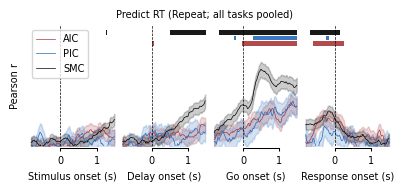

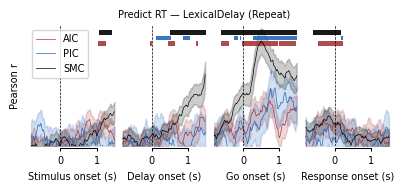

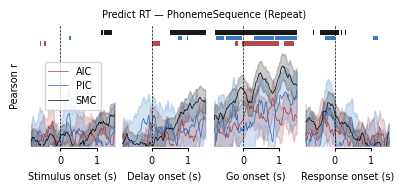

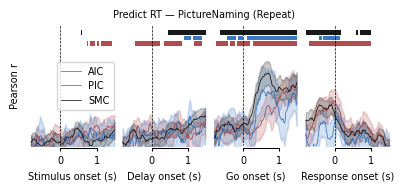

In [8]:
def plot_rt_phase_curves(
    rt_subset: pd.DataFrame,
    *,
    rois,
    phases,
    palette=None,
    ymax=0.2,
    pad=0.01,
    bar_h=0.01,
    sig_threshold=0.1,
    title=None,
):
    if rt_subset.empty:
        raise ValueError('rt_subset empty')
    palette = palette or roi_colors_for(rois)
    palette_map = dict(zip(rois, palette))
    sig_ch = rt_subset.loc[rt_subset['mask'], 'channel'].unique()
    subset = rt_subset[rt_subset['channel'].isin(sig_ch)].copy()

    fig, axes = plt.subplots(
        1, len(phases), figsize=(3 * len(phases) * cm, 4 * cm),
    )
    if len(phases) == 1:
        axes = [axes]
    plt.subplots_adjust(wspace=0)

    for ax, phase in zip(axes, phases):
        phase_df = subset[(subset['phase'] == phase) & (subset['roi'].isin(rois))]
        g = phase_df.groupby('channel')['r2']
        if len(g) == 0:
            ax.set_title(phase, fontsize=fontsize)
            continue
        picks = g.min().ge(-1) & g.max().le(1) & g.max().gt(0)
        picks = picks[picks].index
        plot_df = phase_df[phase_df['channel'].isin(picks)]
        sns.lineplot(
            data=plot_df, x='time', y='r2', hue='roi', hue_order=rois,
            palette=palette, lw=0.5, ax=ax, legend=(ax is axes[0]),
        )
        ax.set_ylabel('Pearson r' if ax is axes[0] else '', fontsize=fontsize)
        ax.set_xlabel(f'{phase} onset (s)', fontsize=fontsize)
        bar_base = ymax + pad
        gap = bar_h * 0.1
        for i, roi in enumerate(rois):
            sig_ratio = (
                subset[(subset['phase'] == phase) & (subset['roi'] == roi)]
                .sort_values('time').groupby('time')['mask'].mean()
            )
            agg = sig_ratio >= sig_threshold
            if agg.any():
                y0 = bar_base + i * (bar_h + gap)
                ax.fill_between(
                    sig_ratio.index.to_numpy(), y0, y0 + bar_h,
                    where=agg.to_numpy(), color=palette_map[roi],
                    alpha=0.9, step='mid', linewidth=0,
                )
        ax.set_ylim(0, bar_base + len(rois) * (bar_h + gap) + bar_h)

    for ax in axes:
        ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
        ax.tick_params(labelsize=7, width=0.75, length=2)
        plt.setp(ax.spines.values(), linewidth=0.75)
        sns.despine(ax=ax, offset=1, trim=True)
        if ax.get_legend() is not None and ax is not axes[0]:
            ax.get_legend().remove()
        elif ax.get_legend() is not None:
            ax.legend(title='', fontsize=7)
        ax.set_yticklabels([]); ax.set_yticks([])
        ax.spines['left'].set_visible(False)
    if title:
        fig.suptitle(title, fontsize=fontsize)
    return fig, axes


if rt_subset.empty:
    print('Skipping temporal curves.')
else:
    fig, _ = plot_rt_phase_curves(
        rt_subset,
        rois=rt_hue_order,
        phases=rt_phases,
        palette=roi_colors_for(rt_hue_order),
        title='Predict RT (Repeat; all tasks pooled)',
    )
    # fig.savefig(export_dir / 'rt_explore_temporal_roi.svg', dpi=300, bbox_inches='tight')
    plt.show()

    # Per-task panels
    for task_name in rt_tasks:
        sub = rt_subset[rt_subset['task'] == task_name]
        if sub.empty:
            print(f'Skip {task_name}: empty')
            continue
        fig, _ = plot_rt_phase_curves(
            sub,
            rois=rt_hue_order,
            phases=rt_phases,
            palette=roi_colors_for(rt_hue_order),
            title=f'Predict RT — {task_name} (Repeat)',
        )
        # fig.savefig(export_dir / f'rt_explore_temporal_{task_name}.svg', dpi=300, bbox_inches='tight')
        plt.show()


## 4. Channel × time heatmap (single ROI)

Replicates SMC / AIC heatmaps from `fig3_rt_legacy`. Non-significant times → NaN.


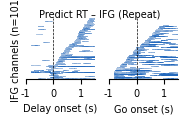

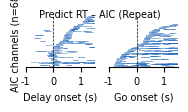

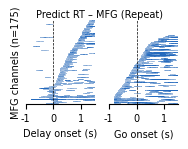

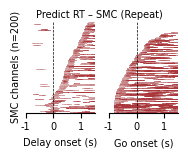

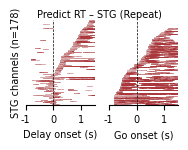

In [23]:
def plot_rt_heatmap(
    rt_subset: pd.DataFrame,
    *,
    roi='SMC',
    phases=('Delay', 'Go'),
    cmap=None,
    vmin=0.0,
    vmax=0.4,
    description='Repeat',
):
    cmap = cmap or blues
    sig = rt_subset[
        (rt_subset['mask'])
        & (rt_subset['roi'] == roi)
        & (rt_subset['phase'] == 'Delay')
        & (rt_subset['time'] >= 0.0)
    ]
    sig_channels = sig['channel'].unique().tolist()
    if not sig_channels:
        print(f'No Delay-significant channels for ROI={roi}')
        return None

    subset = rt_subset[
        (rt_subset['channel'].isin(sig_channels))
        & (rt_subset['description'] == description)
        & (rt_subset['roi'] == roi)
    ].copy()
    subset.loc[~subset['mask'], 'r2'] = np.nan

    def _sorted(phase_name, time_min=None):
        phase_data = subset[subset['phase'] == phase_name]
        if time_min is not None:
            phase_data = phase_data[phase_data['time'] >= time_min]
        first = []
        for ch in sig_channels:
            t = phase_data[(phase_data['channel'] == ch) & phase_data['mask']]['time']
            first.append((ch, t.min() if len(t) else np.inf))
        return [ch for ch, _ in sorted(first, key=lambda x: x[1])]

    phase_sorted = {
        'Delay': _sorted('Delay', time_min=0.0),
        'Go': _sorted('Go'),
        'Stimulus': _sorted('Stimulus'),
        'Response': _sorted('Response'),
    }
    n_ch = len(sig_channels)
    fig, axes = plt.subplots(
        1, len(phases),
        figsize=(2.5 * len(phases) * cm, float(0.01 * n_ch * cm + 1 * cm)),
    )
    if len(phases) == 1:
        axes = [axes]

    for ax, phase in zip(axes, phases):
        sorted_ch = phase_sorted.get(phase, sig_channels)
        phase_data = subset[
            (subset['phase'] == phase) & (subset['channel'].isin(sorted_ch))
        ]
        if phase_data.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            continue
        pivot = phase_data.pivot_table(
            index='channel', columns='time', values='r2', aggfunc='mean',
        ).reindex(index=sorted_ch)
        da = xr.DataArray(
            pivot.values,
            coords={'channel': pivot.index, 'time': pivot.columns.astype(float)},
            dims=['channel', 'time'],
        )
        tvals = da.coords['time'].values.astype(float)
        step = np.diff(tvals).mean() if len(tvals) > 1 else 0.01
        t_edges = np.concatenate(([tvals[0] - step / 2], tvals[:-1] + step / 2, [tvals[-1] + step / 2]))
        c_edges = np.arange(n_ch + 1)
        T, C = np.meshgrid(t_edges, c_edges)
        ax.pcolormesh(T, C, da.values, cmap=cmap, vmin=vmin, vmax=vmax,
                      shading='auto', rasterized=True)
        sns.despine(ax=ax, offset=0, trim=False)
        ax.spines['left'].set_visible(False)
        ax.set_xticks([-1, 0, 1])
        ax.set_xticklabels(['-1', '0', '1'], fontsize=7)
        ax.set_yticks([])
        ax.set_xlabel(f'{phase} onset (s)', fontsize=7)
        ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
        ax.set_ylim(0, n_ch)
        if ax is axes[0]:
            ax.set_ylabel(f'{roi} channels (n={n_ch})', fontsize=7)

    fig.suptitle(f'Predict RT – {roi} ({description})', fontsize=7)
    return fig, axes


if rt_subset.empty:
    print('Skipping heatmaps.')
else:
    for roi, cmap in [('IFG', blues),('AIC', blues),('MFG', blues), ('SMC', reds), ('STG', reds)]:
        out = plot_rt_heatmap(rt_subset, roi=roi, phases=('Delay', 'Go'), cmap=cmap)
        if out is not None:
            fig, _ = out
            # fig.savefig(export_dir / f'rt_explore_heatmap_{roi}.svg', dpi=300, bbox_inches='tight')
            plt.show()


---
# Part 2 — Exploration panels

These go beyond the publication notebooks. Run after Part 1.


## 5. Significant-window onset / peak latency

For each Delay-significant channel: first `mask` time and time of max \(r\).


Latency rows: 1315


n  onset_med  peak_med  peak_r_med
task          roi                                           
LexicalDelay  AG          7       0.16      0.50       0.288
              AIC        26       0.22      0.50       0.275
              AIC–IFG     6       0.33      0.57       0.254
              AIC–MFG     1       0.04      0.22       0.187
              AIC–PrG     1       0.56      0.62       0.207
...                      ..        ...       ...         ...
PictureNaming STGp–STGa   1       0.00      0.00       0.184
              STGp–pTL    1       0.00      0.10       0.362
              TP         24       0.16      0.28       0.201
              TP–MTG      1       0.42      0.46       0.202
              pTL        64       0.17      0.46       0.207

[135 rows x 4 columns]

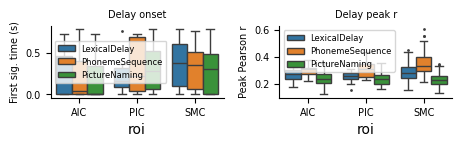

In [10]:
def channel_latency_table(rt_subset, phase='Delay', time_min=0.0, time_max=0.8):
    sub = rt_subset[
        (rt_subset['phase'] == phase)
        & (rt_subset['time'] >= time_min)
        & (rt_subset['time'] <= time_max)
    ].copy()
    rows = []
    for (ch, task), g in sub.groupby(['channel', 'task']):
        sig = g[g['mask']]
        if sig.empty:
            continue
        peak_row = g.loc[g['r2'].idxmax()]
        rows.append({
            'channel': ch,
            'subject': g['subject'].iloc[0],
            'task': task,
            'roi': g['roi'].iloc[0],
            'hemi': g['hemi'].iloc[0],
            'y': g['y'].iloc[0],
            'onset': float(sig['time'].min()),
            'peak_time': float(peak_row['time']),
            'peak_r': float(peak_row['r2']),
            'n_sig_times': int(sig.shape[0]),
        })
    return pd.DataFrame(rows)


lat = channel_latency_table(rt_subset) if not rt_subset.empty else pd.DataFrame()
print(f'Latency rows: {len(lat)}')
if not lat.empty:
    display(lat.groupby(['task', 'roi']).agg(
        n=('channel', 'nunique'),
        onset_med=('onset', 'median'),
        peak_med=('peak_time', 'median'),
        peak_r_med=('peak_r', 'median'),
    ).round(3))

    plot_rois = [r for r in rt_hue_order if r in set(lat['roi'])]
    fig, axes = plt.subplots(1, 2, figsize=(12 * cm, 4 * cm))
    sns.boxplot(
        data=lat[lat['roi'].isin(plot_rois)], x='roi', y='onset',
        hue='task', order=plot_rois, ax=axes[0], fliersize=1,
    )
    axes[0].set_ylabel('First sig. time (s)', fontsize=fontsize)
    axes[0].set_title('Delay onset', fontsize=fontsize)
    sns.boxplot(
        data=lat[lat['roi'].isin(plot_rois)], x='roi', y='peak_r',
        hue='task', order=plot_rois, ax=axes[1], fliersize=1,
    )
    axes[1].set_ylabel('Peak Pearson r', fontsize=fontsize)
    axes[1].set_title('Delay peak r', fontsize=fontsize)
    for ax in axes:
        ax.tick_params(labelsize=fontsize)
        sns.despine(ax=ax)
        if ax.get_legend():
            ax.legend(fontsize=6, title='')
    plt.tight_layout()
    plt.show()


## 6. Peak \(r\) vs anterior–posterior (\(y\))

Is stronger RT encoding more anterior (AIC-like) within speech ROIs?


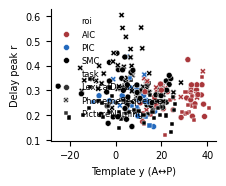

In [11]:
if lat.empty:
    print('Skipping anatomy scatter (no latency table).')
else:
    plot_df = lat[lat['roi'].isin(rt_hue_order)].copy()
    fig, ax = plt.subplots(figsize=(6 * cm, 5 * cm))
    sns.scatterplot(
        data=plot_df, x='y', y='peak_r', hue='roi', style='task',
        hue_order=rt_hue_order, palette=roi_colors_for(rt_hue_order),
        s=18, ax=ax,
    )
    ax.set_xlabel('Template y (A↔P)', fontsize=fontsize)
    ax.set_ylabel('Delay peak r', fontsize=fontsize)
    ax.tick_params(labelsize=fontsize)
    ax.legend(fontsize=6, title='', frameon=False)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()


## 7. Cross-task \(r(t)\) overlay (one ROI)

Same ROI, Delay phase, mean \(r(t)\) across tasks.


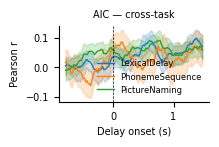

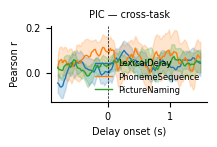

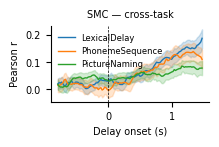

In [12]:
def plot_cross_task_delay(rt_subset, roi='AIC', phase='Delay'):
    sub = rt_subset[(rt_subset['roi'] == roi) & (rt_subset['phase'] == phase)].copy()
    if sub.empty:
        print(f'No data for {roi}/{phase}')
        return
    # keep channels that are sig somewhere in this ROI/phase
    sig_ch = sub.loc[sub['mask'], 'channel'].unique()
    sub = sub[sub['channel'].isin(sig_ch)]
    fig, ax = plt.subplots(figsize=(6 * cm, 4 * cm))
    sns.lineplot(
        data=sub, x='time', y='r2', hue='task',
        hue_order=rt_tasks, lw=1, ax=ax,
    )
    ax.axvline(0, color='k', ls='--', lw=0.5)
    ax.set_xlabel(f'{phase} onset (s)', fontsize=fontsize)
    ax.set_ylabel('Pearson r', fontsize=fontsize)
    ax.set_title(f'{roi} — cross-task', fontsize=fontsize)
    ax.tick_params(labelsize=fontsize)
    ax.legend(fontsize=6, title='', frameon=False)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()


if rt_subset.empty:
    print('Skipping cross-task overlay.')
else:
    for roi in rt_hue_order:
        plot_cross_task_delay(rt_subset, roi=roi, phase='Delay')


## 8. Subject stability

Per-subject counts of Delay-significant channels and median peak \(r\).


In [24]:
if lat.empty:
    print('Skipping subject stability.')
else:
    subj = (
        lat.groupby(['task', 'subject'])
        .agg(n_ch=('channel', 'nunique'), peak_r_med=('peak_r', 'median'))
        .reset_index()
    )
    display(subj.groupby('task')[['n_ch', 'peak_r_med']].describe().round(3))

    fig, axes = plt.subplots(1, 2, figsize=(12 * cm, 4 * cm))
    sns.boxplot(data=subj, x='task', y='n_ch', ax=axes[0], fliersize=1)
    axes[0].set_ylabel('N Delay-sig channels', fontsize=fontsize)
    axes[0].tick_params(axis='x', rotation=20, labelsize=fontsize)
    sns.boxplot(data=subj, x='task', y='peak_r_med', ax=axes[1], fliersize=1)
    axes[1].set_ylabel('Median peak r', fontsize=fontsize)
    axes[1].tick_params(axis='x', rotation=20, labelsize=fontsize)
    for ax in axes:
        ax.tick_params(labelsize=fontsize)
        sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()


KeyError: 'subject'

## 9. Inventory QC

Quick completeness check against expected subject counts.


In [ ]:
if rt.empty:
    print('No RT loaded.')
else:
    inv = (
        rt.groupby(['task', 'subject'])
        .agg(n_files_rows=('phase', 'nunique'), n_ch=('channel', 'nunique'))
        .reset_index()
    )
    summary = inv.groupby('task').agg(
        n_subjects=('subject', 'nunique'),
        median_ch=('n_ch', 'median'),
    )
    display(summary)
    print('Known gaps from cohort audit: LexicalDelay D0127 (hammers Unknown); '
          'PictureNaming D0100 (OOM on re-run).')


## Next (optional, not wired yet)

- Behavioral RT histograms (needs epoch metadata from BIDS, not in RT H5)
- Peak-window predicted vs actual RT scatter (needs trial-level predictions)
- Overlap Venn: RT-sig ∩ HGA-sig ∩ decoding-sig (`viz/fig6` style)
- PictureNaming split by `recording` modality (image/sound/text)
